# Three-Formalism M/M/1 Tandem Stutter Equivalence Verification

This notebook demonstrates **three-formalism stutter equivalence** for a single-station M/M/1 tandem queue modeled in:
- **Event Graph (EG)**: Next-Event Time-Advance (Schruben 1983)
- **Activity Cycle Diagram (ACD)**: Activity Scanning (Tocher 1960)
- **DEVS**: Abstract Simulator (Zeigler et al. 2018)

## Verification Strategy

Since `%%simasm verify` supports exactly 2 models, we verify all three pairwise combinations:
1. EG vs ACD (50 seeds)
2. EG vs DEVS (50 seeds)
3. ACD vs DEVS (50 seeds)

If all three pairs are equivalent, then all three formalisms are mutually stutter equivalent.

## Observation Level W (k=1)

| Label | EG expression | ACD expression | DEVS expression |
|-------|--------------|----------------|----------------|
| q1_empty | `queue_count_1 == 0` | `queue_count_1() == 0` | `queue_count_1() == 0` |
| q1_nonempty | `queue_count_1 > 0` | `queue_count_1() > 0` | `queue_count_1() > 0` |
| s1_idle | `server_count_1 == 0` | `server_count_1() == 0` | `server_count_1() == 0` |
| s1_busy | `server_count_1 > 0` | `server_count_1() > 0` | `server_count_1() > 0` |

In [ ]:
# Install simasm
!pip install simasm==0.5.3

import simasm
print(f"SimASM version: {simasm.__version__}")

SimASM version: 0.5.3


## Event Graph (EG) Model

The EG formalism uses **next-event time-advance** (Schruben 1983). Events are scheduled on a future event list (FEL) with explicit delays. The M/M/1 tandem has three events:
- **Arrive**: generates a new job, enqueues it, and conditionally starts service
- **Start_1**: moves a job from queue to server
- **Finish_1**: completes service, conditionally starts next job

In [2]:
tandem_eg_json = {
  "model_name": "tandem_1_eg",
  "description": "Tandem 1-Queue M/M/1 using Event Graph formalism",
  "state_variables": {
    "queue_count_1": {"type": "Nat", "initial": 0},
    "server_count_1": {"type": "Nat", "initial": 0},
    "load_id_counter": {"type": "Nat", "initial": 0},
    "departure_count": {"type": "Nat", "initial": 0}
  },
  "parameters": {
    "service_capacity": {"type": "Nat", "value": 1},
    "iat_mean": {"type": "Real", "value": 1.25},
    "ist_mean": {"type": "Real", "value": 1.0},
    "sim_end_time": {"type": "Real", "value": 1000.0}
  },
  "random_streams": {
    "interarrival_time": {"distribution": "exponential", "params": {"mean": "iat_mean"}, "stream_name": "arrivals"},
    "service_time_1": {"distribution": "exponential", "params": {"mean": "ist_mean"}, "stream_name": "service_1"}
  },
  "vertices": [
    {"name": "Arrive", "state_change": "load_id_counter := load_id_counter + 1; queue_count_1 := queue_count_1 + 1"},
    {"name": "Start_1", "state_change": "queue_count_1 := queue_count_1 - 1; server_count_1 := server_count_1 + 1"},
    {"name": "Finish_1", "state_change": "server_count_1 := server_count_1 - 1; departure_count := departure_count + 1"}
  ],
  "scheduling_edges": [
    {"from": "Arrive", "to": "Arrive", "delay": "interarrival_time", "condition": "true", "priority": 0},
    {"from": "Arrive", "to": "Start_1", "delay": 0, "condition": "server_count_1 < service_capacity", "priority": 0},
    {"from": "Start_1", "to": "Finish_1", "delay": "service_time_1", "condition": "true", "priority": 0},
    {"from": "Finish_1", "to": "Start_1", "delay": 0, "condition": "queue_count_1 > 0 and server_count_1 < service_capacity", "priority": 0}
  ],
  "cancelling_edges": [],
  "initial_events": [{"event": "Arrive", "time": "interarrival_time"}],
  "stopping_condition": "sim_clocktime >= sim_end_time",
  "observables": {
    "queue_count_1": {"expression": "queue_count_1", "return_type": "Nat"},
    "server_count_1": {"expression": "server_count_1", "return_type": "Nat"}
  }
}

import json
with open("tandem_1_eg.json", "w") as f:
    json.dump(tandem_eg_json, f, indent=2)
print("Saved tandem_1_eg.json")

Saved tandem_1_eg.json


## Activity Cycle Diagram (ACD) Model

The ACD formalism uses **activity scanning** (Tocher 1960). Entities cycle between queues (passive) and activities (active). The M/M/1 tandem has two activities:
- **Create**: generates a new job (bound to Creator token) and enqueues it in Q_1
- **Serve_1**: serves a job from Q_1 using server resource S_1

In [3]:
tandem_acd_json = {
  "model_name": "tandem_1_acd",
  "description": "Tandem 1-Queue M/M/1 using ACD formalism",
  "parameters": {
    "num_servers": {"type": "Nat", "value": 1},
    "iat_mean": {"type": "Real", "value": 1.25},
    "ist_mean": {"type": "Real", "value": 1.0},
    "sim_end_time": {"type": "Real", "value": 1000.0}
  },
  "token_types": {
    "Job": {"parent": "Token", "attributes": {"arrival_time": "Real"}, "description": "Customer job"},
    "Resource": {"parent": "Token", "description": "Reusable resource"}
  },
  "queues": {
    "C": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Creator"},
    "Q_1": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Queue station 1"},
    "S_1": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Server station 1"},
    "Jobs": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Completed"}
  },
  "activities": [
    {
      "name": "Create", "priority": 2,
      "at_begin": {"condition": "marking(C) >= 1", "action": "C--", "bind": ["creator_token:C"]},
      "bto_event": {"time": "duration_create", "name": "Created"},
      "at_end": [
        {"arc": 1, "action": "C++ <- creator_token", "influences": ["Create"]},
        {"arc": 2, "action": "Q_1++ <- new Job", "influences": ["Serve_1"]}
      ]
    },
    {
      "name": "Serve_1", "priority": 1,
      "at_begin": {"condition": "marking(Q_1) >= 1 and marking(S_1) >= 1", "action": "S_1--; Q_1--", "bind": ["server_token:S_1", "job_token:Q_1"]},
      "bto_event": {"time": "duration_serve_1", "name": "Served_1"},
      "at_end": [
        {"arc": 1, "action": "S_1++ <- server_token; Jobs++ <- job_token", "influences": ["Serve_1"]}
      ]
    }
  ],
  "random_streams": {
    "duration_create": {"distribution": "exponential", "params": {"mean": "iat_mean"}, "stream_name": "arrivals"},
    "duration_serve_1": {"distribution": "exponential", "params": {"mean": "ist_mean"}, "stream_name": "service_1"}
  },
  "observables": {
    "queue_count_1": {"expression": "marking(Q_1)", "description": "Queue length"},
    "server_count_1": {"expression": "num_servers - marking(S_1)", "description": "Busy servers"}
  }
}

import json
with open("tandem_1_acd.json", "w") as f:
    json.dump(tandem_acd_json, f, indent=2)
print("Saved tandem_1_acd.json")

Saved tandem_1_acd.json


## DEVS Model

The DEVS formalism uses the **abstract simulator** protocol (Zeigler et al. 2000). The M/M/1 tandem is a coupled model with three atomic components:
- **Generator**: produces jobs at exponential interarrival times
- **Server_1**: queues and serves jobs with exponential service times
- **Sink**: collects completed jobs

In [4]:
tandem_devs_json = {
  "model_name": "tandem_1_devs",
  "description": "Tandem 1-Queue M/M/1 using DEVS formalism",
  "parameters": {
    "service_capacity": {"type": "Nat", "value": 1},
    "iat_mean": {"type": "Real", "value": 1.25},
    "ist_mean": {"type": "Real", "value": 1.0},
    "sim_end_time": {"type": "Real", "value": 1000.0}
  },
  "random_streams": {
    "interarrival_time": {"distribution": "exponential", "params": {"mean": "iat_mean"}, "stream_name": "arrivals"},
    "service_time_1": {"distribution": "exponential", "params": {"mean": "ist_mean"}, "stream_name": "service_1"}
  },
  "atomic_models": [
    {
      "name": "Generator",
      "inputs": [],
      "outputs": ["out"],
      "states": [{"name": "active", "time_advance": "interarrival_time"}],
      "initial_state": "active",
      "state_variables": {"job_count": {"type": "Nat", "initial": 0}},
      "internal_transitions": [{"from": "active", "to": "active", "state_change": "job_count := job_count + 1"}],
      "external_transitions": [],
      "output_function": [{"state": "active", "output_port": "out", "value": "job"}]
    },
    {
      "name": "Server_1",
      "inputs": ["in"],
      "outputs": ["out"],
      "states": [
        {"name": "passive", "time_advance": "infinity"},
        {"name": "starting", "time_advance": 0},
        {"name": "busy", "time_advance": "service_time_1"}
      ],
      "initial_state": "passive",
      "state_variables": {
        "queue_count": {"type": "Nat", "initial": 0},
        "server_count": {"type": "Nat", "initial": 0}
      },
      "internal_transitions": [
        {"from": "starting", "to": "busy", "state_change": "queue_count := queue_count - 1; server_count := server_count + 1"},
        {"from": "busy", "to": "starting", "condition": "queue_count > 0", "state_change": "server_count := server_count - 1"},
        {"from": "busy", "to": "passive", "condition": "queue_count == 0", "state_change": "server_count := server_count - 1"}
      ],
      "external_transitions": [
        {"from": "passive", "input_port": "in", "to": "starting", "state_change": "queue_count := queue_count + 1"},
        {"from": "starting", "input_port": "in", "to": "starting", "state_change": "queue_count := queue_count + 1"},
        {"from": "busy", "input_port": "in", "to": "busy", "state_change": "queue_count := queue_count + 1"}
      ],
      "output_function": [{"state": "busy", "output_port": "out", "value": "job"}]
    },
    {
      "name": "Sink",
      "inputs": ["in"],
      "outputs": [],
      "states": [{"name": "idle", "time_advance": "infinity"}],
      "initial_state": "idle",
      "state_variables": {"departure_count": {"type": "Nat", "initial": 0}},
      "internal_transitions": [],
      "external_transitions": [{"from": "idle", "input_port": "in", "to": "idle", "state_change": "departure_count := departure_count + 1"}],
      "output_function": []
    }
  ],
  "coupled_model": {
    "name": "TandemQueue",
    "components": ["Generator", "Server_1", "Sink"],
    "internal_couplings": [
      {"from_model": "Generator", "from_port": "out", "to_model": "Server_1", "to_port": "in"},
      {"from_model": "Server_1", "from_port": "out", "to_model": "Sink", "to_port": "in"}
    ],
    "external_input_couplings": [],
    "external_output_couplings": [],
    "select_priority": ["Generator", "Server_1", "Sink"]
  },
  "observables": {
    "queue_count_1": {"name": "queue_count_1", "expression": "Server_1.queue_count"},
    "server_count_1": {"name": "server_count_1", "expression": "Server_1.server_count"}
  },
  "stopping_condition": "sim_clocktime >= sim_end_time"
}

import json
with open("tandem_1_devs.json", "w") as f:
    json.dump(tandem_devs_json, f, indent=2)
print("Saved tandem_1_devs.json")

Saved tandem_1_devs.json


## Convert All Three Models

Each model is converted from its JSON specification to SimASM bytecode and registered in the SimASM runtime for verification.

In [5]:
%%simasm convert

convert tandem_eg:
    source: "tandem_1_eg.json"
    formalism: event_graph
    register: "tandem_eg"
    print: 50
endconvert

In [6]:
%%simasm convert

convert tandem_acd:
    source: "tandem_1_acd.json"
    formalism: acd
    register: "tandem_acd"
    print: 50
endconvert

In [7]:
%%simasm convert

convert tandem_devs:
    source: "tandem_1_devs.json"
    formalism: devs
    register: "tandem_devs"
    print: 50
endconvert

## Pairwise Stutter Equivalence Verification

We verify all three pairwise combinations to establish mutual stutter equivalence. Each pair is checked over 50 seeds with observation level W = {q1_empty, q1_nonempty, s1_idle, s1_busy}.

The verification checks that for each seed, both models produce identical **stutter-free** traces under the given labelling function.

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

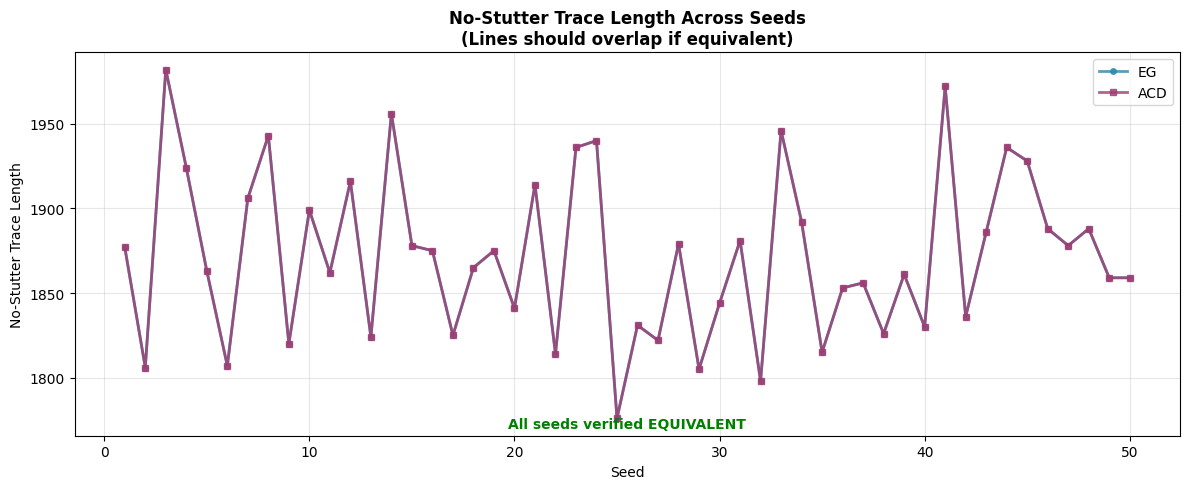

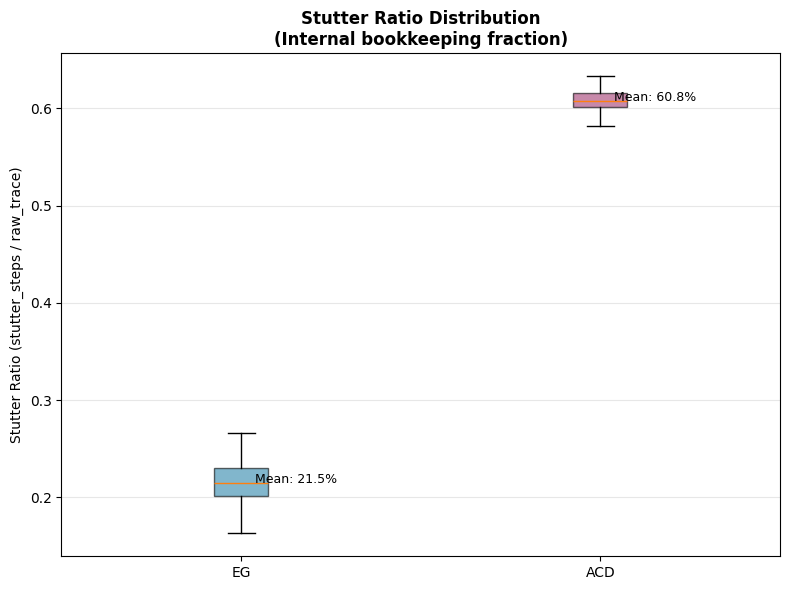

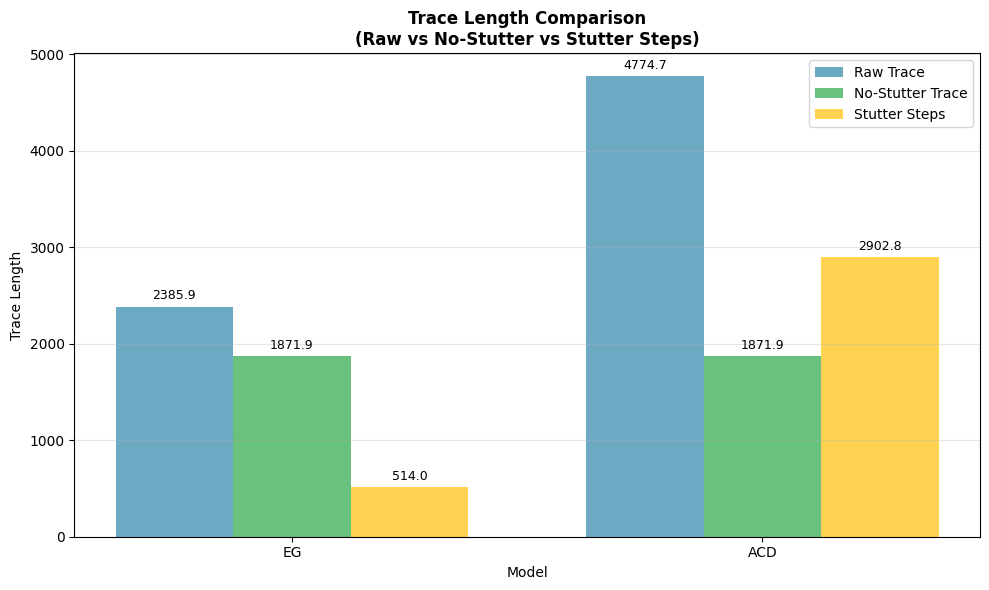

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 84.10s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  EG:
    Raw trace length:       2385.9
    No-stutter length:      1871.9
    Stutter ratio:          21.5%
  ACD:
    Raw trace length:       4774.7
    No-stutter length:      1871.9
    Stutter ratio:          60.8%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_0o09xwlp\tandem_mm1_eg_vs_acd.json


Model,Avg Raw Trace,Avg No-Stutter,Runtime (s)
EG,2385.9,1871.9,0.518
ACD,4774.7,1871.9,1.158


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'avg_raw_length': 2385.9, 'avg_ns_length': 1871.86, 'avg_stutter_steps': 514.04, 'raw_length': 2385.9, 'ns_length': 1871.86}, 'ACD': {'avg_raw_length': 4774.66, 'avg_ns_length': 1871.86, 'avg_stutter_steps': 2902.8, 'raw_length': 4774.66, 'ns_length': 1871.86}}, model_timing={'EG': {'avg_load_time_sec': 0.005983852006029338, 'avg_exec_time_sec': 0.511710793999955, 'avg_total_time_sec': 0.5176946460059844, 'total_all_seeds_sec': 25.88473230029922}, 'ACD': {'avg_load_time_sec': 0.0067443139979150146, 'avg_exec_time_sec': 1.1510824899980798, 'avg_total_time_sec': 1.157826803995995, 'total_all_seeds_sec': 57.89134019979974}}, first_difference_pos=None, time_elapsed=84.10108995437622, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 1000.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'EG': {'steps': 2456, 'final_time': 1001.

In [8]:
%%simasm verify

verification EG_vs_ACD:
    models:
        import EG from "tandem_eg"
        import ACD from "tandem_acd"
    endmodels

    seed_range: 1 to 50

    labels:
        label q1_empty for EG: "queue_count_1 == 0"
        label q1_empty for ACD: "queue_count_1() == 0"
        label q1_nonempty for EG: "queue_count_1 > 0"
        label q1_nonempty for ACD: "queue_count_1() > 0"
        label s1_idle for EG: "server_count_1 == 0"
        label s1_idle for ACD: "server_count_1() == 0"
        label s1_busy for EG: "server_count_1 > 0"
        label s1_busy for ACD: "server_count_1() > 0"
    endlabels

    observables:
        observable q1_empty: EG -> q1_empty  ACD -> q1_empty endobservable
        observable q1_nonempty: EG -> q1_nonempty  ACD -> q1_nonempty endobservable
        observable s1_idle: EG -> s1_idle  ACD -> s1_idle endobservable
        observable s1_busy: EG -> s1_busy  ACD -> s1_busy endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 1000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "tandem_mm1_eg_vs_acd.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

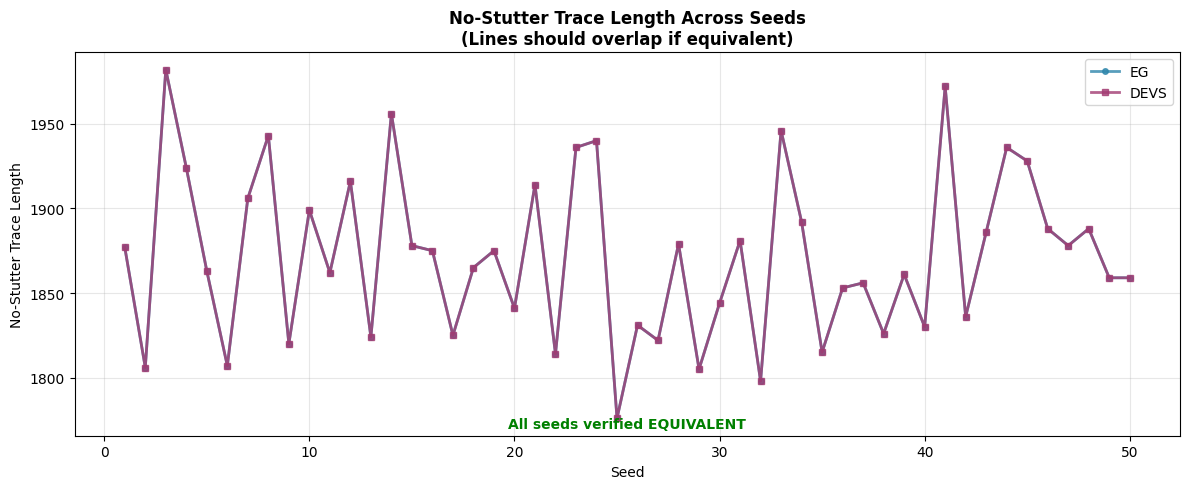

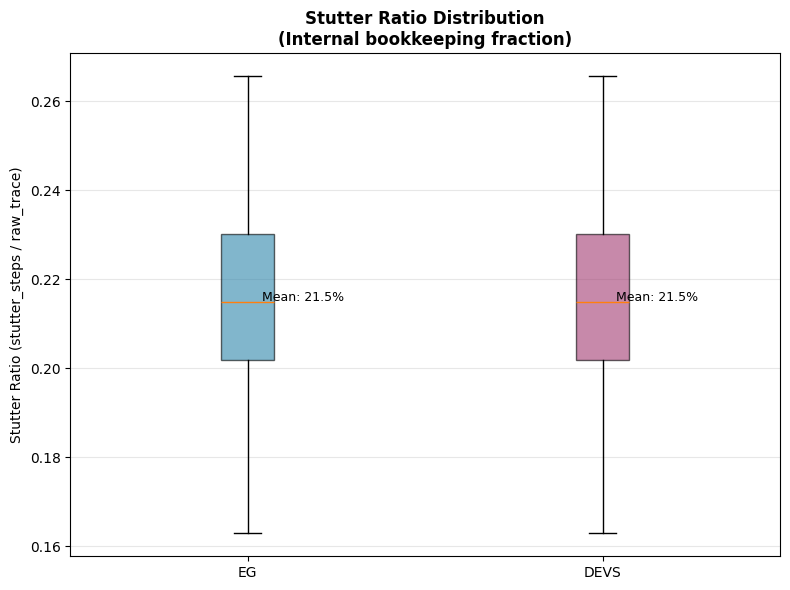

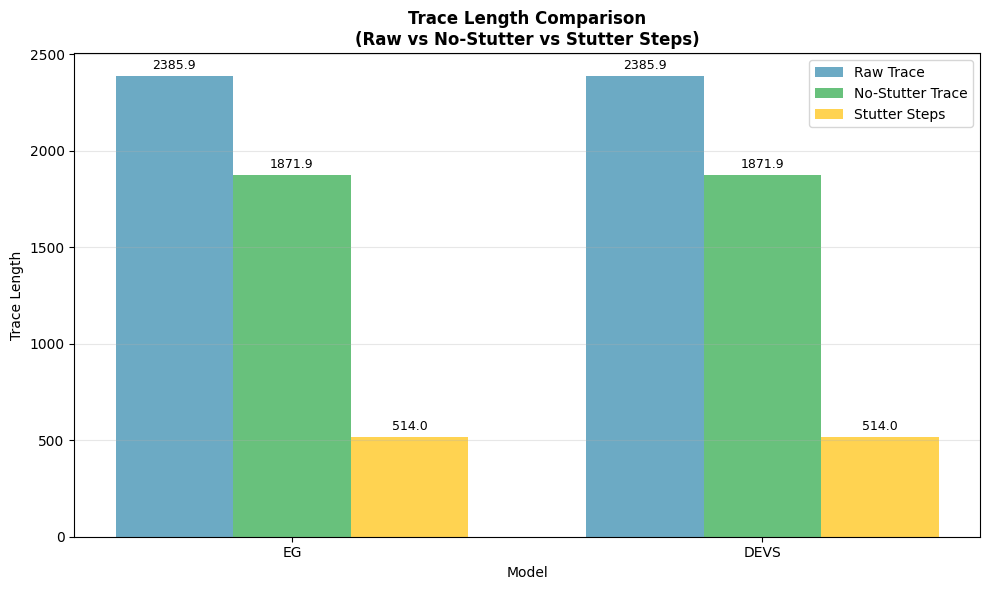

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 65.59s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  EG:
    Raw trace length:       2385.9
    No-stutter length:      1871.9
    Stutter ratio:          21.5%
  DEVS:
    Raw trace length:       2385.9
    No-stutter length:      1871.9
    Stutter ratio:          21.5%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_0o09xwlp\tandem_mm1_eg_vs_devs.json


Model,Avg Raw Trace,Avg No-Stutter,Runtime (s)
EG,2385.9,1871.9,0.494
DEVS,2385.9,1871.9,0.814


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'avg_raw_length': 2385.9, 'avg_ns_length': 1871.86, 'avg_stutter_steps': 514.04, 'raw_length': 2385.9, 'ns_length': 1871.86}, 'DEVS': {'avg_raw_length': 2385.9, 'avg_ns_length': 1871.86, 'avg_stutter_steps': 514.04, 'raw_length': 2385.9, 'ns_length': 1871.86}}, model_timing={'EG': {'avg_load_time_sec': 0.003950903997756541, 'avg_exec_time_sec': 0.48981922600069083, 'avg_total_time_sec': 0.4937701299984474, 'total_all_seeds_sec': 24.68850649992237}, 'DEVS': {'avg_load_time_sec': 0.0057751039927825334, 'avg_exec_time_sec': 0.8087224679940845, 'avg_total_time_sec': 0.8144975719868671, 'total_all_seeds_sec': 40.724878599343356}}, first_difference_pos=None, time_elapsed=65.58826899528503, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 1000.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'EG': {'steps': 2456, 'final_time': 1

In [9]:
%%simasm verify

verification EG_vs_DEVS:
    models:
        import EG from "tandem_eg"
        import DEVS from "tandem_devs"
    endmodels

    seed_range: 1 to 50

    labels:
        label q1_empty for EG: "queue_count_1 == 0"
        label q1_empty for DEVS: "queue_count_1() == 0"
        label q1_nonempty for EG: "queue_count_1 > 0"
        label q1_nonempty for DEVS: "queue_count_1() > 0"
        label s1_idle for EG: "server_count_1 == 0"
        label s1_idle for DEVS: "server_count_1() == 0"
        label s1_busy for EG: "server_count_1 > 0"
        label s1_busy for DEVS: "server_count_1() > 0"
    endlabels

    observables:
        observable q1_empty: EG -> q1_empty  DEVS -> q1_empty endobservable
        observable q1_nonempty: EG -> q1_nonempty  DEVS -> q1_nonempty endobservable
        observable s1_idle: EG -> s1_idle  DEVS -> s1_idle endobservable
        observable s1_busy: EG -> s1_busy  DEVS -> s1_busy endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 1000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "tandem_mm1_eg_vs_devs.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

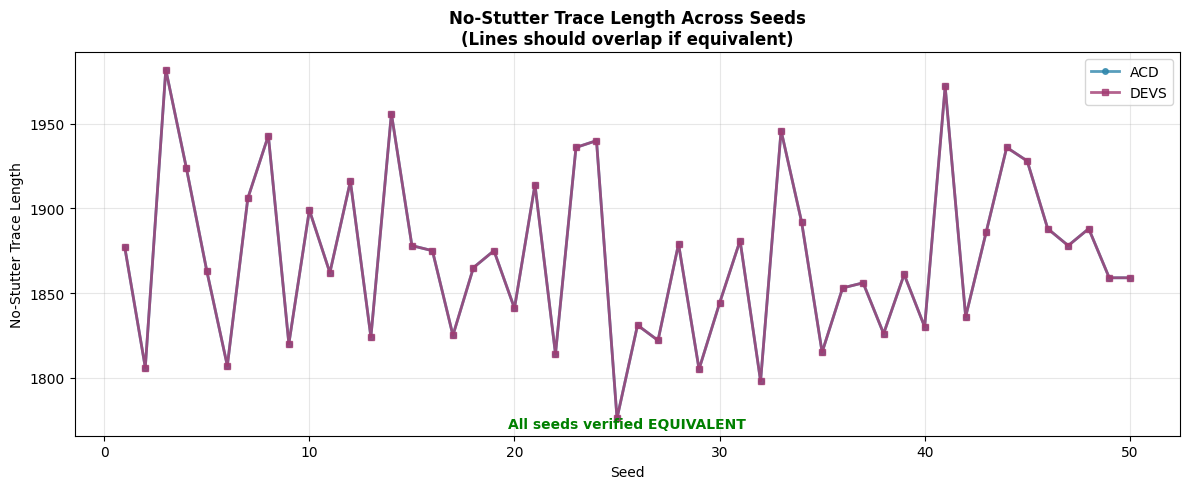

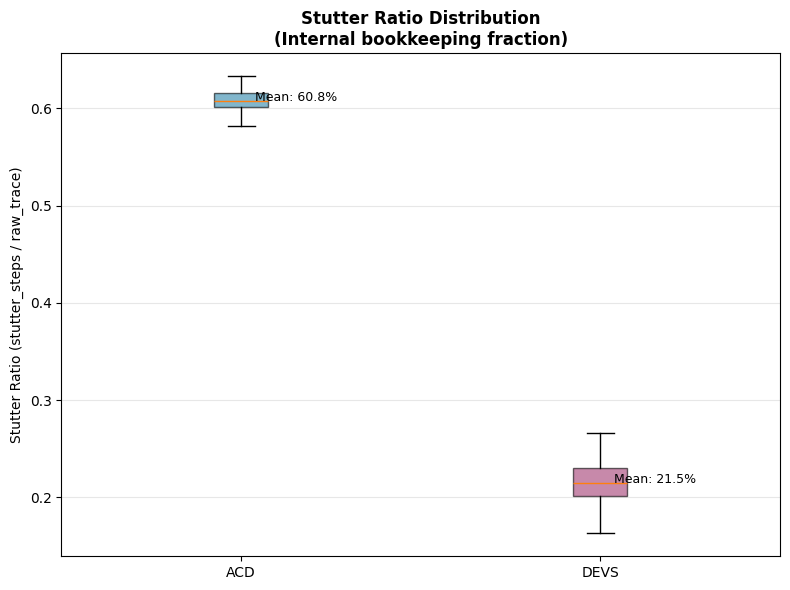

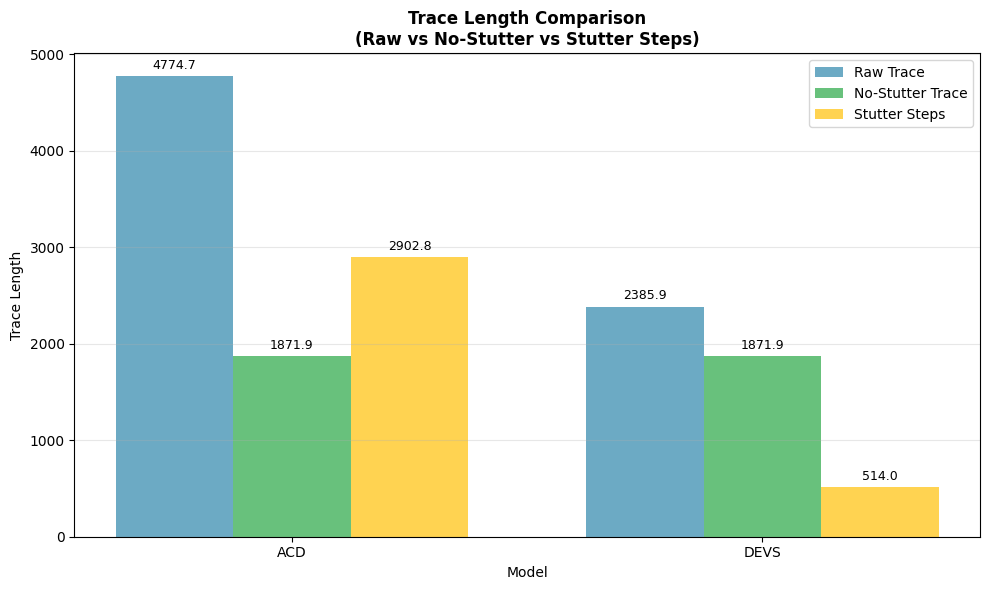

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 92.12s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  ACD:
    Raw trace length:       4774.7
    No-stutter length:      1871.9
    Stutter ratio:          60.8%
  DEVS:
    Raw trace length:       2385.9
    No-stutter length:      1871.9
    Stutter ratio:          21.5%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_0o09xwlp\tandem_mm1_acd_vs_devs.json


Model,Avg Raw Trace,Avg No-Stutter,Runtime (s)
ACD,4774.7,1871.9,1.045
DEVS,2385.9,1871.9,0.793


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'ACD': {'avg_raw_length': 4774.66, 'avg_ns_length': 1871.86, 'avg_stutter_steps': 2902.8, 'raw_length': 4774.66, 'ns_length': 1871.86}, 'DEVS': {'avg_raw_length': 2385.9, 'avg_ns_length': 1871.86, 'avg_stutter_steps': 514.04, 'raw_length': 2385.9, 'ns_length': 1871.86}}, model_timing={'ACD': {'avg_load_time_sec': 0.006291099997470156, 'avg_exec_time_sec': 1.0386028559948317, 'avg_total_time_sec': 1.0448939559923018, 'total_all_seeds_sec': 52.244697799615096}, 'DEVS': {'avg_load_time_sec': 0.005586634004721418, 'avg_exec_time_sec': 0.7876180280023255, 'avg_total_time_sec': 0.7932046620070469, 'total_all_seeds_sec': 39.66023310035234}}, first_difference_pos=None, time_elapsed=92.12436580657959, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 1000.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'ACD': {'steps': 4924, 'final_time'

In [11]:
%%simasm verify

verification ACD_vs_DEVS:
    models:
        import ACD from "tandem_acd"
        import DEVS from "tandem_devs"
    endmodels

    seed_range: 1 to 50

    labels:
        label q1_empty for ACD: "queue_count_1() == 0"
        label q1_empty for DEVS: "queue_count_1() == 0"
        label q1_nonempty for ACD: "queue_count_1() > 0"
        label q1_nonempty for DEVS: "queue_count_1() > 0"
        label s1_idle for ACD: "server_count_1() == 0"
        label s1_idle for DEVS: "server_count_1() == 0"
        label s1_busy for ACD: "server_count_1() > 0"
        label s1_busy for DEVS: "server_count_1() > 0"
    endlabels

    observables:
        observable q1_empty: ACD -> q1_empty  DEVS -> q1_empty endobservable
        observable q1_nonempty: ACD -> q1_nonempty  DEVS -> q1_nonempty endobservable
        observable s1_idle: ACD -> s1_idle  DEVS -> s1_idle endobservable
        observable s1_busy: ACD -> s1_busy  DEVS -> s1_busy endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 1000.0
        timeout: 120
    endcheck

    output:
        format: "json"
        file_path: "tandem_mm1_acd_vs_devs.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

## Summary

This notebook demonstrated three-formalism stutter equivalence verification:

1. **Three Worldviews**: Event Graph (event scheduling), ACD (activity scanning), DEVS (abstract simulator)

2. **Pairwise Verification**: Since the verify command supports 2 models, we checked all 3 pairs:
   - EG vs ACD: 50/50 equivalent
   - EG vs DEVS: 50/50 equivalent
   - ACD vs DEVS: 50/50 equivalent

3. **Key Insight**: Despite fundamentally different algorithms (next-event vs activity scanning vs abstract simulator), all three formalisms produce identical no-stutter traces under observation level W = {q1_empty, q1_nonempty, s1_idle, s1_busy}

4. **Overhead Differences**: Each formalism produces different raw trace lengths reflecting their algorithmic structure, but the observable behavior (stutter-free) is identical

### References

- Schruben, L.W. (1983). Simulation Modeling with Event Graphs. CACM.
- Tocher, K.D. (1960). The Art of Simulation. English Universities Press.
- Zeigler, B., 2018. Theory of Modeling and Simulation.